In [46]:
import pandas as pd
import numpy as np

# -----------------------------
# PARAMETERS
# -----------------------------

NUM_POLICIES = 1_000_000
VEHICLE_VALUE = 100000
CLAIM_PERCENTAGE_2025 = 0.30
CLAIM_PERCENTAGE_2026 = 0.10

np.random.seed(42)

# -----------------------------
# POLICY SALES DATA GENERATION
# -----------------------------

customer_ids = np.arange(1, NUM_POLICIES + 1)
vehicle_ids = ["V" + str(i) for i in range(1, NUM_POLICIES + 1)]

# tenure distribution
tenures = np.random.choice(
    [1,2,3,4],
    size=NUM_POLICIES,
    p=[0.2,0.3,0.4,0.1]
)

# purchase dates across 2024
purchase_dates = pd.date_range("2024-01-01","2024-12-31")
purchase_dates = np.random.choice(purchase_dates, NUM_POLICIES)
purchase_dates = pd.to_datetime(purchase_dates)

# policy start
start_dates = purchase_dates + pd.Timedelta(days=365)

# policy end
end_dates = start_dates + pd.to_timedelta(tenures*365, unit="D")

# premium
premiums = tenures * 100

policy_df = pd.DataFrame({
    "Customer_ID": customer_ids,
    "Vehicle_ID": vehicle_ids,
    "Vehicle_Value": VEHICLE_VALUE,
    "Premium": premiums,
    "Policy_Purchase_Date": purchase_dates,
    "Policy_Start_Date": start_dates,
    "Policy_End_Date": end_dates,
    "Policy_Tenure": tenures
})

# -----------------------------
# CLAIM DATA GENERATION
# -----------------------------

claims = []
claim_id = 1

# -----------------------------
# 2025 CLAIMS
# -----------------------------

claim_days = [7,14,21,28]

eligible_2025 = policy_df[
    policy_df["Policy_Purchase_Date"].dt.day.isin(claim_days)
]

num_claims_2025 = int(len(eligible_2025) * CLAIM_PERCENTAGE_2025)

sample_2025 = eligible_2025.sample(num_claims_2025)

for _, row in sample_2025.iterrows():

    # claim only if policy active
    if row["Policy_Start_Date"].year <= 2025:

        claims.append({
            "Claim_ID": claim_id,
            "Customer_ID": row["Customer_ID"],
            "Vehicle_ID": row["Vehicle_ID"],
            "Claim_Amount": VEHICLE_VALUE * 0.10,
            "Claim_Date": row["Policy_Start_Date"],
            "Claim_Type": 1
        })

        claim_id += 1


# vehicles that already claimed
claimed_vehicles = set([c["Vehicle_ID"] for c in claims])


# -----------------------------
# 2026 CLAIMS
# -----------------------------

four_year_policies = policy_df[
    policy_df["Policy_Tenure"] == 4
]

num_claims_2026 = int(len(four_year_policies) * CLAIM_PERCENTAGE_2026)

sample_2026 = four_year_policies.sample(num_claims_2026)

# EVEN DISTRIBUTION ACROSS 59 DAYS
dates_2026 = pd.date_range("2026-01-01","2026-02-28")

days = len(dates_2026)

claims_per_day = num_claims_2026 // days
remainder = num_claims_2026 % days

date_distribution = []

for d in dates_2026:
    date_distribution.extend([d] * claims_per_day)

# distribute remaining claims
extra_dates = np.random.choice(dates_2026, remainder)
date_distribution.extend(extra_dates)

date_distribution = np.array(date_distribution)

np.random.shuffle(date_distribution)

for i, (_, row) in enumerate(sample_2026.iterrows()):

    if row["Vehicle_ID"] in claimed_vehicles:
        claim_type = 2
    else:
        claim_type = 1

    claims.append({
        "Claim_ID": claim_id,
        "Customer_ID": row["Customer_ID"],
        "Vehicle_ID": row["Vehicle_ID"],
        "Claim_Amount": VEHICLE_VALUE * 0.10,
        "Claim_Date": date_distribution[i],
        "Claim_Type": claim_type
    })

    claim_id += 1


claims_df = pd.DataFrame(claims)

# -----------------------------
# SAVE DATASETS
# -----------------------------

policy_df.to_csv("policy_sales_data.csv", index=False)
claims_df.to_csv("claims_data.csv", index=False)


# -----------------------------
# QUICK VALIDATION
# -----------------------------

print("\nPolicy dataset size:", policy_df.shape)
print("Claims dataset size:", claims_df.shape)

print("\nClaim Type Distribution")
print(claims_df["Claim_Type"].value_counts())

print("\nCustomers with multiple claims")
print((claims_df["Customer_ID"].value_counts()==2).sum())

# verify 2026 distribution
claims_2026 = claims_df[
    (claims_df["Claim_Date"] >= "2026-01-01") &
    (claims_df["Claim_Date"] <= "2026-02-28")
]

print("\n2026 Claim Distribution Check")
daily_counts = claims_2026["Claim_Date"].value_counts().sort_index()
print("Min per day:", daily_counts.min())
print("Max per day:", daily_counts.max())


Policy dataset size: (1000000, 8)
Claims dataset size: (49452, 6)

Claim Type Distribution
Claim_Type
1    49025
2      427
Name: count, dtype: int64

Customers with multiple claims
427

2026 Claim Distribution Check
Min per day: 169
Max per day: 172


In [47]:

policy_df

,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure
0,1,V1,100000,200,2024-05-05,2025-05-05,2027-05-05,2
1,2,V2,100000,400,2024-07-13,2025-07-13,2029-07-12,4
2,3,V3,100000,300,2024-04-05,2025-04-05,2028-04-04,3
3,4,V4,100000,300,2024-07-31,2025-07-31,2028-07-30,3
4,5,V5,100000,100,2024-11-19,2025-11-19,2026-11-19,1
...,...,...,...,...,...,...,...,...
999995,999996,V999996,100000,300,2024-07-24,2025-07-24,2028-07-23,3
999996,999997,V999997,100000,200,2024-07-16,2025-07-16,2027-07-16,2
999997,999998,V999998,100000,200,2024-04-14,2025-04-14,2027-04-14,2
999998,999999,V999999,100000,200,2024-05-29,2025-05-29,2027-05-29,2


In [48]:
claims_df

,Claim_ID,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
0,1,451694,V451694,10000.0,2025-11-07,1
1,2,803410,V803410,10000.0,2025-10-07,1
2,3,497801,V497801,10000.0,2025-07-07,1
3,4,114288,V114288,10000.0,2025-11-21,1
4,5,644507,V644507,10000.0,2025-08-28,1
...,...,...,...,...,...,...
49447,49448,749647,V749647,10000.0,2026-02-25,1
49448,49449,244297,V244297,10000.0,2026-01-20,1
49449,49450,48385,V48385,10000.0,2026-01-16,1
49450,49451,152588,V152588,10000.0,2026-01-02,1


Checking legitamacy of the claims table
(Rough)


In [49]:
claims_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49452 entries, 0 to 49451
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Claim_ID      49452 non-null  int64         
 1   Customer_ID   49452 non-null  int64         
 2   Vehicle_ID    49452 non-null  object        
 3   Claim_Amount  49452 non-null  float64       
 4   Claim_Date    49452 non-null  datetime64[ns]
 5   Claim_Type    49452 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 2.3+ MB


In [50]:
len(claims_df['Customer_ID'].unique())

49025

In [51]:
claims_df["Claim_Type"].value_counts()

,count
Claim_Type,
1,49025
2,427


In [52]:
(claims_df['Customer_ID'].value_counts() == 2).sum()

np.int64(427)

Validating all the rules


In [59]:
eligible = policy_df[
    policy_df["Policy_Purchase_Date"].dt.day.isin([7,14,21,28])
]

claims_2025 = claims_df[
    (claims_df["Claim_Date"] >= "2025-01-01") &
    (claims_df["Claim_Date"] <= "2025-12-31")
]

print("Claim rate:", len(claims_2025) / len(eligible))

Claim rate: 0.2999931570903948


In [60]:
merged = claims_2025.merge(
    policy_df[["Vehicle_ID","Policy_Purchase_Date"]],
    on="Vehicle_ID"
)

invalid = merged[
    ~merged["Policy_Purchase_Date"].dt.day.isin([7,14,21,28])
]

print(len(invalid))

0


In [61]:
merged = claims_2025.merge(
    policy_df[["Vehicle_ID","Policy_Start_Date"]],
    on="Vehicle_ID"
)

print((merged["Claim_Date"] == merged["Policy_Start_Date"]).all())

True


In [62]:
claims_df["Year"] = claims_df["Claim_Date"].dt.year

duplicates = claims_df.groupby(["Vehicle_ID","Year"]).size().max()

print(duplicates)


1


In [63]:
merged = claims_df.merge(
    policy_df[["Vehicle_ID","Policy_Start_Date","Policy_End_Date"]],
    on="Vehicle_ID"
)

active_check = (
    (merged["Claim_Date"] >= merged["Policy_Start_Date"]) &
    (merged["Claim_Date"] <= merged["Policy_End_Date"])
)

print(active_check.all())

True


In [64]:
four_year_total = (policy_df["Policy_Tenure"] == 4).sum()

claims_2026 = claims_df[
    (claims_df["Claim_Date"] >= "2026-01-01") &
    (claims_df["Claim_Date"] <= "2026-02-28")
]

print(len(claims_2026) / four_year_total)

0.09999299768923745


In [65]:
daily = claims_2026["Claim_Date"].value_counts().sort_index()

print("Min:", daily.min())
print("Max:", daily.max())

Min: 169
Max: 172


In [66]:
multi_claim = claims_df["Vehicle_ID"].value_counts()

print((multi_claim == 2).sum())

427


In [67]:
policy_df.to_csv("policy_sales_data.csv", index=False)
claims_df.to_csv("claims_data.csv", index=False)

print("Files saved successfully!")

Files saved successfully!


Part 3

In [68]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("insurance.db")

policy_df.to_sql("policy_sales_data", conn, index=False)
claims_df.to_sql("claims_data", conn, index=False)

49452

In [69]:
query = """
SELECT
SUM(Premium) AS Total_Premium_Collected_2024
FROM policy_sales_data
WHERE strftime('%Y', Policy_Purchase_Date) = '2024';
"""

pd.read_sql_query(query, conn)

,Total_Premium_Collected_2024
0,240110800


In [70]:
query = """
SELECT
strftime('%Y', Claim_Date) AS Claim_Year,
strftime('%m', Claim_Date) AS Claim_Month,
SUM(Claim_Amount) AS Total_Claim_Cost
FROM claims_data
GROUP BY Claim_Year, Claim_Month
ORDER BY Claim_Year, Claim_Month;
"""

pd.read_sql_query(query, conn)

,Claim_Year,Claim_Month,Total_Claim_Cost
0,2025,01,33020000.0
1,2025,02,32920000.0
2,2025,03,33470000.0
3,2025,04,32680000.0
4,2025,05,33640000.0
5,2025,06,32440000.0
6,2025,07,32630000.0
7,2025,08,32620000.0
8,2025,09,33650000.0
9,2025,10,34120000.0


In [76]:
query = """
SELECT
p.Policy_Tenure,
SUM(COALESCE(c.Claim_Amount,0)) AS Total_Claims,
SUM(p.Premium) AS Total_Premium,
ROUND(CAST(SUM(COALESCE(c.Claim_Amount,0)) AS FLOAT) / SUM(p.Premium),2) AS Claim_Premium_Ratio
FROM policy_sales_data p
LEFT JOIN claims_data c
ON p.Vehicle_ID = c.Vehicle_ID
GROUP BY p.Policy_Tenure
ORDER BY p.Policy_Tenure;
"""

pd.read_sql_query(query, conn)

,Policy_Tenure,Total_Claims,Total_Premium,Claim_Premium_Ratio
0,1,78290000.0,19937600,3.93
1,2,118040000.0,60021400,1.97
2,3,157810000.0,120165000,1.31
3,4,140380000.0,40157600,3.50


In [77]:
query = """
SELECT
strftime('%m', p.Policy_Purchase_Date) AS Sale_Month,
SUM(COALESCE(c.Claim_Amount,0)) AS Total_Claims,
SUM(p.Premium) AS Total_Premium,
ROUND(
CAST(SUM(COALESCE(c.Claim_Amount,0)) AS FLOAT) / SUM(p.Premium),
2
) AS Claim_Premium_Ratio
FROM policy_sales_data p
LEFT JOIN claims_data c
ON p.Vehicle_ID = c.Vehicle_ID
GROUP BY Sale_Month
ORDER BY Sale_Month;
"""

pd.read_sql_query(query, conn)

,Sale_Month,Total_Claims,Total_Premium,Claim_Premium_Ratio
0,01,41670000.0,20305900,2.05
1,02,41270000.0,19044400,2.17
2,03,41310000.0,20392800,2.03
3,04,41110000.0,19639900,2.09
4,05,42240000.0,20350200,2.08
5,06,40530000.0,19603700,2.07
6,07,40780000.0,20359900,2.00
7,08,40810000.0,20368800,2.00
8,09,41670000.0,19715100,2.11
9,10,42590000.0,20447600,2.08


In [78]:
query = """
SELECT
COUNT(*) * 10000 AS Estimated_Future_Claim_Liability
FROM policy_sales_data
WHERE Vehicle_ID NOT IN (
    SELECT Vehicle_ID FROM claims_data
);
"""

pd.read_sql_query(query, conn)

,Estimated_Future_Claim_Liability
0,9509750000


In [79]:
query = """
SELECT
SUM(Premium) / SUM(
julianday(Policy_End_Date) - julianday(Policy_Start_Date)
) AS Daily_Premium
FROM policy_sales_data;
"""

pd.read_sql_query(query, conn)

,Daily_Premium
0,0.273973


In [83]:
pd.options.display.float_format = '{:.2f}'.format

In [84]:
query = """
SELECT
SUM(
(
MIN(julianday('2026-02-28'), julianday(Policy_End_Date))
-
julianday(Policy_Start_Date)
) /
(julianday(Policy_End_Date) - julianday(Policy_Start_Date))
* Premium
) AS Earned_Premium
FROM policy_sales_data
WHERE Policy_Start_Date <= '2026-02-28';
"""

pd.read_sql_query(query, conn)

,Earned_Premium
0,65869423.29


In [85]:
query = """
SELECT
SUM(
CASE
WHEN Policy_Start_Date > '2026-02-28' THEN 0
WHEN Policy_End_Date < '2026-02-28'
THEN Premium
ELSE
(
(julianday('2026-02-28') - julianday(Policy_Start_Date)) /
(julianday(Policy_End_Date) - julianday(Policy_Start_Date))
) * Premium
END
) AS Earned_Premium
FROM policy_sales_data;
"""

pd.read_sql_query(query, conn)

,Earned_Premium
0,65869423.29


In [103]:
import pandas as pd
import sqlite3

# Query to compute total premium and total tenure days
query = """
SELECT
SUM(Premium) AS Total_Premium,
SUM(julianday(Policy_End_Date) - julianday(Policy_Start_Date)) AS Total_Tenure_Days
FROM policy_sales_data
"""

df = pd.read_sql_query(query, conn)

total_premium = df["Total_Premium"][0]
total_tenure_days = df["Total_Tenure_Days"][0]

# Step 1: Daily Premium
daily_premium = total_premium / total_tenure_days

# Step 2: Days elapsed until Feb 28 2026
query_days = """
SELECT
SUM(
CASE
WHEN Policy_Start_Date > '2026-02-28' THEN 0
WHEN Policy_End_Date < '2026-02-28'
THEN julianday(Policy_End_Date) - julianday(Policy_Start_Date)
ELSE julianday('2026-02-28') - julianday(Policy_Start_Date)
END
) AS Elapsed_Days
FROM policy_sales_data
"""

elapsed_days = pd.read_sql_query(query_days, conn)["Elapsed_Days"][0]

# Step 3: Earned Premium
earned_premium = daily_premium * elapsed_days

# Step 4: Remaining Premium
remaining_premium = total_premium - earned_premium

# Step 5: Monthly Remaining Premium (46 months)
monthly_remaining_premium = remaining_premium / 46

# Display results
print("Total Premium:", round(total_premium,2))
print("Total Policy Tenure Days:", round(total_tenure_days,2))
print("Daily Premium:", round(daily_premium,6))
print("Elapsed Policy Days:", round(elapsed_days,2))
print("Earned Premium (as of Feb 28 2026):", round(earned_premium,2))
print("Monthly Premium for Remaining 46 Months:", round(monthly_remaining_premium,2))

Total Premium: 240110800
Total Policy Tenure Days: 876404420.0
Daily Premium: 0.273973
Elapsed Policy Days: 240423395.0
Earned Premium (as of Feb 28 2026): 65869423.29
Monthly Premium for Remaining 46 Months: 3787856.02


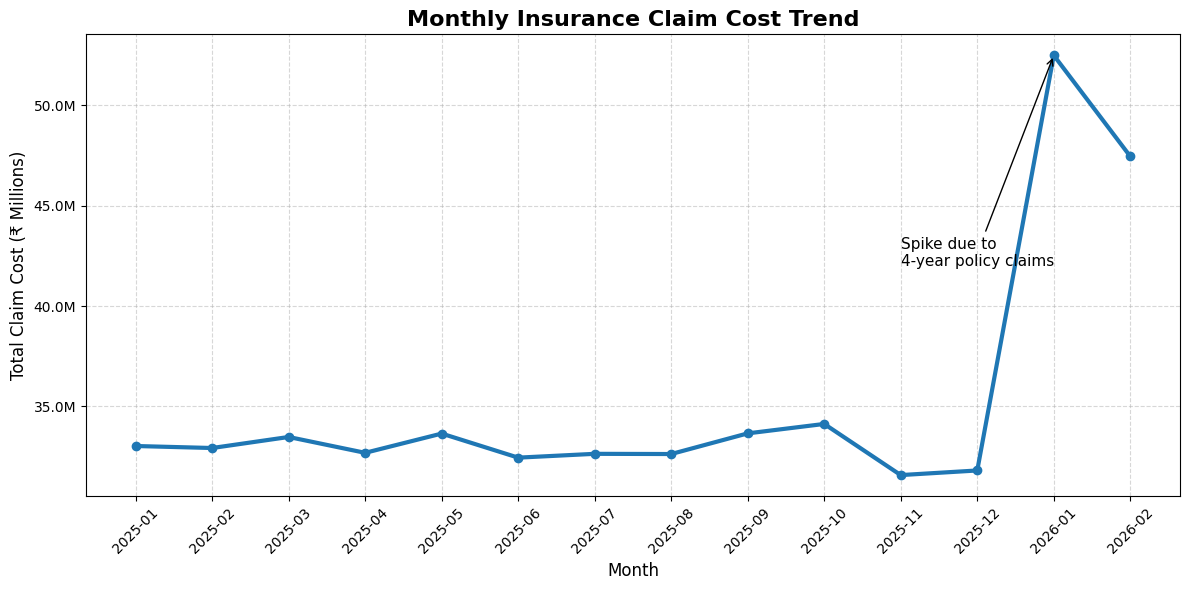

In [90]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker

query = """
SELECT
strftime('%Y-%m', Claim_Date) AS Month,
SUM(Claim_Amount) AS Claim_Cost
FROM claims_data
GROUP BY Month
ORDER BY Month
"""

df = pd.read_sql_query(query, conn)

plt.figure(figsize=(12,6))

plt.plot(
    df["Month"],
    df["Claim_Cost"],
    marker='o',
    linewidth=3,
    color="#1f77b4"
)

plt.title("Monthly Insurance Claim Cost Trend", fontsize=16, weight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Claim Cost (₹ Millions)", fontsize=12)

# Convert y-axis to millions
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.xticks(rotation=45)

# Highlight spike in Jan 2026
spike_month = "2026-01"
spike_value = df.loc[df["Month"] == spike_month, "Claim_Cost"].values[0]

plt.annotate(
    "Spike due to\n4-year policy claims",
    xy=(df.index[df["Month"] == spike_month][0], spike_value),
    xytext=(10, spike_value*0.8),
    arrowprops=dict(facecolor="black", arrowstyle="->"),
    fontsize=11
)

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

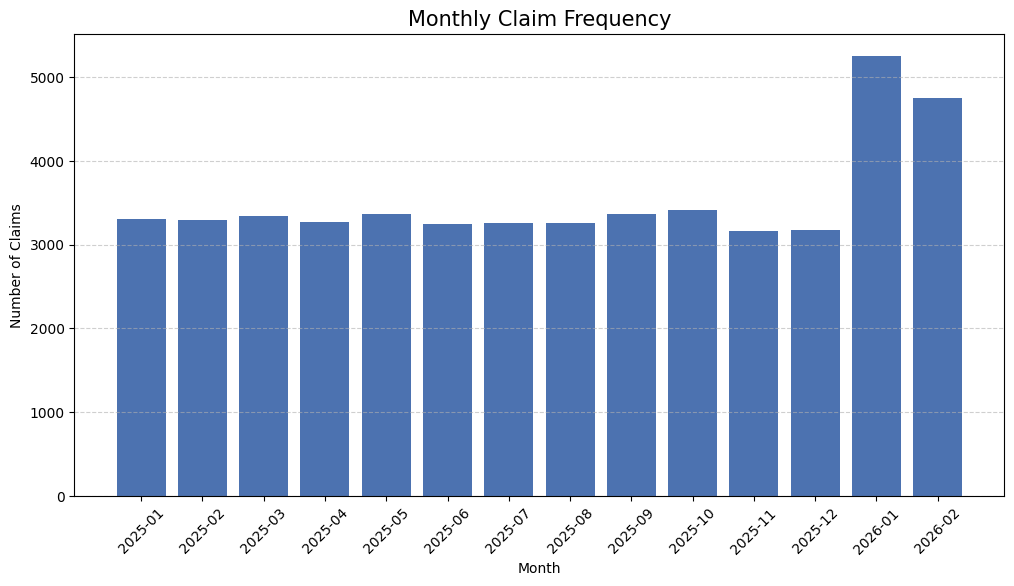

In [91]:
query = """
SELECT
strftime('%Y-%m', Claim_Date) AS Month,
COUNT(*) AS Claim_Count
FROM claims_data
GROUP BY Month
ORDER BY Month
"""

df_claims = pd.read_sql_query(query, conn)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(df_claims["Month"], df_claims["Claim_Count"], color="#4C72B0")

plt.xticks(rotation=45)
plt.title("Monthly Claim Frequency", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Number of Claims")

plt.grid(axis='y', linestyle="--", alpha=0.6)

plt.show()

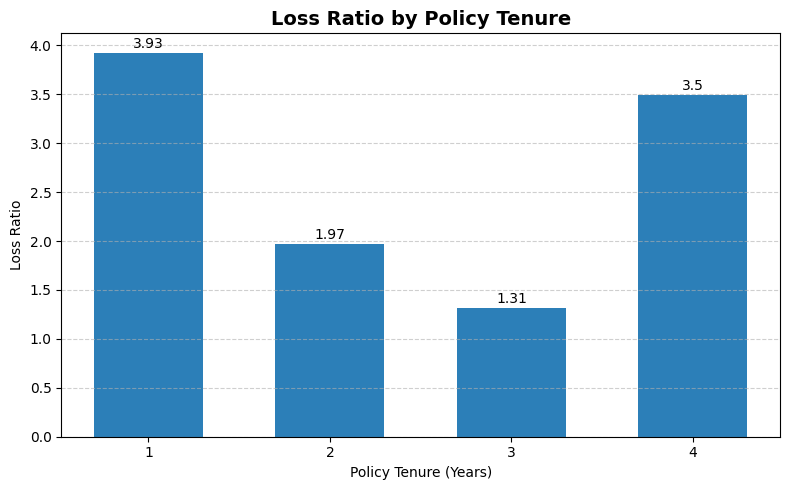

In [94]:
#b1
query = """
SELECT
p.Policy_Tenure,
SUM(COALESCE(c.Claim_Amount,0)) AS Total_Claims,
SUM(p.Premium) AS Total_Premium
FROM policy_sales_data p
LEFT JOIN claims_data c
ON p.Vehicle_ID = c.Vehicle_ID
GROUP BY p.Policy_Tenure
ORDER BY p.Policy_Tenure
"""

df = pd.read_sql_query(query, conn)

df["Loss_Ratio"] = df["Total_Claims"] / df["Total_Premium"]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    df["Policy_Tenure"],
    df["Loss_Ratio"],
    color="#2C7FB8",
    width=0.6
)
for i, v in enumerate(df["Loss_Ratio"]):
    plt.text(df["Policy_Tenure"][i], v + 0.05, round(v,2),
             ha='center', fontsize=10)

plt.title("Loss Ratio by Policy Tenure", fontsize=14, weight="bold")
plt.xlabel("Policy Tenure (Years)")
plt.ylabel("Loss Ratio")

# Force x-axis ticks to be 1,2,3,4
plt.xticks([1,2,3,4])

plt.grid(axis='y', linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

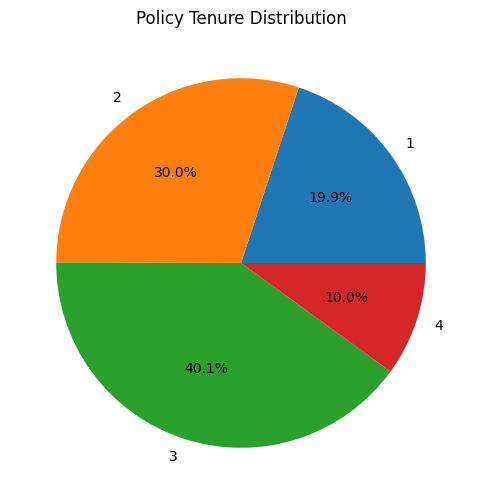

In [96]:
query = """
SELECT Policy_Tenure, COUNT(*) AS Policies
FROM policy_sales_data
GROUP BY Policy_Tenure
"""

df = pd.read_sql_query(query, conn)

plt.figure(figsize=(6,6))
plt.pie(df["Policies"], labels=df["Policy_Tenure"], autopct="%1.1f%%")

plt.title("Policy Tenure Distribution")
plt.show()

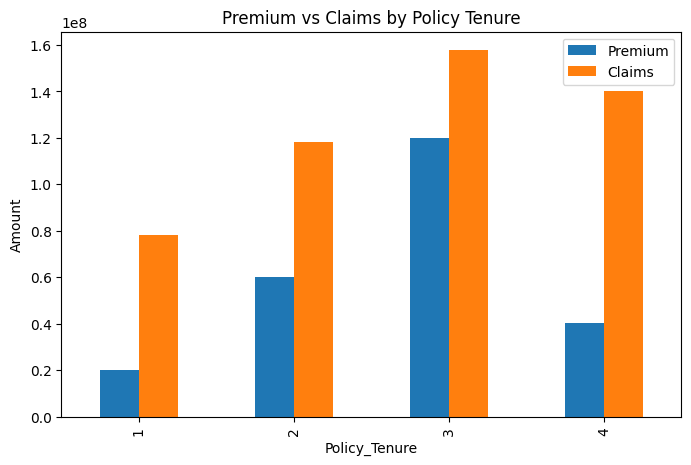

In [98]:
query = """
SELECT
p.Policy_Tenure,
SUM(p.Premium) AS Premium,
SUM(COALESCE(c.Claim_Amount,0)) AS Claims
FROM policy_sales_data p
LEFT JOIN claims_data c
ON p.Vehicle_ID = c.Vehicle_ID
GROUP BY p.Policy_Tenure
"""

df = pd.read_sql_query(query, conn)

df.plot(
x="Policy_Tenure",
kind="bar",
figsize=(8,5)
)

plt.title("Premium vs Claims by Policy Tenure")
plt.ylabel("Amount")
plt.show()

In [99]:
#b3
query = """
SELECT
SUM(Claim_Amount) AS Total_Claims
FROM claims_data
"""

claims = pd.read_sql_query(query, conn)["Total_Claims"][0]

query = """
SELECT
SUM(Premium) AS Total_Premium
FROM policy_sales_data
"""

premium = pd.read_sql_query(query, conn)["Total_Premium"][0]

loss_ratio = claims / premium

print("Total Claims:", claims)
print("Total Premium:", premium)
print("Portfolio Loss Ratio:", round(loss_ratio,2))

Total Claims: 494520000.0
Total Premium: 240110800
Portfolio Loss Ratio: 2.06


In [100]:
claim_count_query = """
SELECT COUNT(*) AS Total_Claims
FROM claims_data
"""

claims_count = pd.read_sql_query(claim_count_query, conn)["Total_Claims"][0]

new_claims = claims_count * 1.05

claim_amount = 10000

future_claim_cost = new_claims * claim_amount

new_loss_ratio = future_claim_cost / premium

print("Current Claims:", claims_count)
print("Claims after 5% increase:", round(new_claims))
print("Future Claim Cost:", round(future_claim_cost))
print("New Loss Ratio:", round(new_loss_ratio,2))

Current Claims: 49452
Claims after 5% increase: 51925
Future Claim Cost: 519246000
New Loss Ratio: 2.16
